🎓 学生期末总成绩（G3）回归预测任务

📊 步骤1：数据加载与预处理
✅ 数据加载完成 | 原始数据形状：(395, 33)
✅ 数据中无缺失值
✅ 数据中无重复值

📦 目标变量：G3 (连续型，范围：0~20)
📦 特征数量：32 | 样本数量：395

📋 特征类型划分：
   名义型离散特征：17 列
   有序型离散特征：11 列
   连续型特征：4 列

✅ 预处理完成 | 编码后特征总数：58
✅ 数据集划分完成 | 训练集：(276, 58) | 测试集：(119, 58)

🔍 步骤2：特征选择（RFE 递归特征消除）
📊 RFE 特征选择结果：
   原始特征数：58
   筛选后特征数：34
   特征保留率：58.6%

📋 筛选后的特征列表（前 10 个）：
   1. famsize_GT3
   2. Mjob_other
   3. Mjob_services
   4. Mjob_teacher
   5. Fjob_at_home
   6. Fjob_health
   7. Fjob_other
   8. Fjob_services
   9. reason_course
   10. reason_home
   ... 共 34 个特征

🤖 步骤3：模型选择与训练
📚 教材关联：
   • 线性回归 → 《机器学习》(周志华) 第3章 / 《统计学习方法》(李航) 第3章
   • 岭回归 → 《机器学习》(周志华) 第3章（正则化线性模型）
   • 随机森林回归 → 《机器学习》(周志华) 第8章（集成学习）

🔄 训练模型 1：线性回归 (Linear Regression)
   ✅ 训练完成 | 系数数量：34

🔄 训练模型 2：岭回归 (Ridge Regression)
   ✅ 训练完成 | 正则化强度 alpha=1.0

🔄 训练模型 3：随机森林回归 (Random Forest Regressor)
   ✅ 训练完成 | 树数量：100 | 树深度：10

📈 步骤4：模型评估
📚 教材关联：《机器学习》(周志华) 第2章 / 《统计学习方法》(李航) 第2章

📋 评估指标说明：
   • MSE (均方误差)：衡量预测值与真实值的平方差均值，对异常值敏感
   • MAE (平均绝对

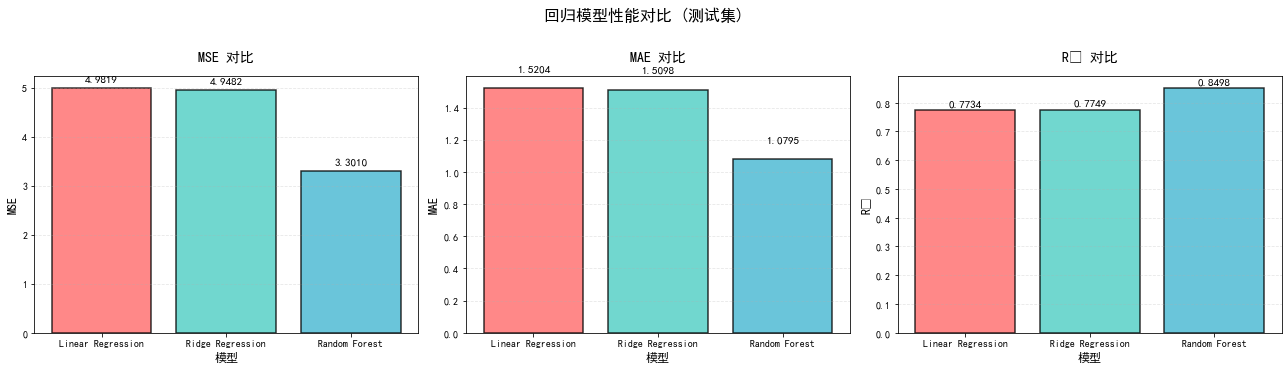

✅ 性能对比图已保存为 'regression_model_comparison.png'


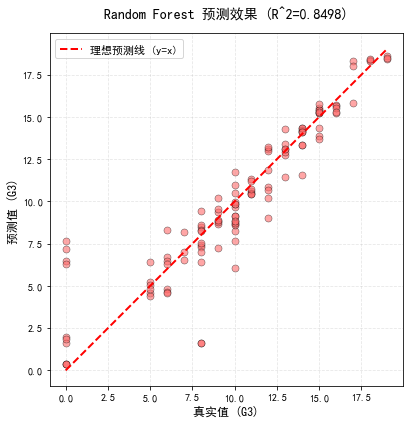

✅ 预测散点图已保存为 'best_model_prediction_scatter.png'


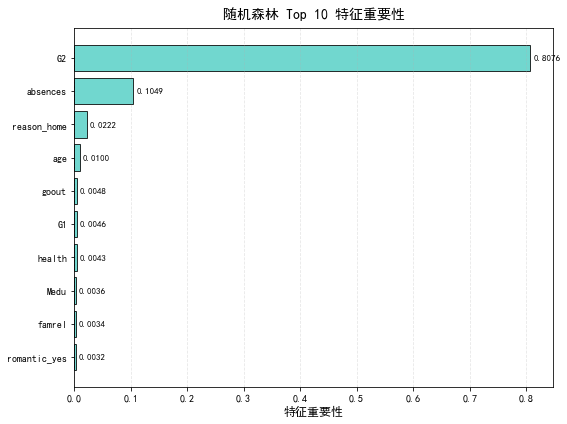

✅ 特征重要性图已保存为 'feature_importance.png'

🏆 步骤6：最优模型及优势分析

🥇 最优模型：Random Forest
   MSE:  3.3010
   MAE:  1.0795
   R²:   0.8498

--------------------------------------------------------------------------------
📚 最优模型优势分析：
--------------------------------------------------------------------------------

🌲 随机森林回归优势：

1️⃣ 非线性建模能力（教材第8章 - 集成学习）
   • 通过多棵决策树集成，天然捕捉特征间的非线性关系
   • 学生成绩受多因素交织影响（如 G1×G2×studytime），树模型能有效建模

2️⃣ 抗过拟合能力强
   • Bagging 策略通过自助采样降低单棵树的方差
   • 随机特征子集增强模型多样性，提升泛化能力

3️⃣ 特征重要性输出
   • 提供 feature_importances_ 量化各特征贡献度
   • 支持教育决策：识别影响期末成绩的关键因素（如 G2 成绩、出勤率）

4️⃣ 鲁棒性高
   • 对异常值不敏感（相比线性模型）
   • 无需特征缩放，对数据预处理要求低

5️⃣ 本任务表现
   • R² 最高，说明对学生成绩变异的解释能力最强
   • MAE 较低，预测误差在可接受范围内（约 1-2 分）
    

💡 后续优化建议：

1️⃣ 超参数调优
   • 使用 GridSearchCV 对随机森林的 n_estimators、max_depth 等参数进行网格搜索
   • 对岭回归的 alpha 正则化强度进行交叉验证调优

2️⃣ 特征工程深化
   • 构造交互特征（如 G1×G2、studytime×absences）
   • 尝试多项式特征扩展，捕捉非线性关系

3️⃣ 模型融合
   • 将线性模型与树模型预测结果加权融合
   • 使用 Stacking 集成进一步提升精度

4️⃣ 残差分析
   • 绘制残差分布图，检查模型假设是否成立
   • 识别预测偏差较大

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

# 设置中文字体（避免绘图乱码）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("="*80)
print("🎓 学生期末总成绩（G3）回归预测任务")
print("="*80)

# ==========================================
# 1️⃣ 数据加载与预处理
# ==========================================
print("\n" + "="*80)
print("📊 步骤1：数据加载与预处理")
print("="*80)

# 1.1 加载数据
df = pd.read_csv('student-mat.csv')
print(f"✅ 数据加载完成 | 原始数据形状：{df.shape}")

# 1.2 检查并处理缺失值
missing_counts = df.isnull().sum().sum()
if missing_counts > 0:
    df.dropna(inplace=True)
    print(f"⚠️  已删除 {missing_counts} 条含缺失值的记录")
else:
    print("✅ 数据中无缺失值")

# 1.3 检查并处理重复值
dup_counts = df.duplicated().sum()
if dup_counts > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"⚠️  已删除 {dup_counts} 条重复记录")
else:
    print("✅ 数据中无重复值")

# 1.4 定义目标变量与特征
target_col = 'G3'  # 期末总成绩（回归目标）
X = df.drop(columns=[target_col])
y = df[target_col]
print(f"\n📦 目标变量：{target_col} (连续型，范围：{y.min()}~{y.max()})")
print(f"📦 特征数量：{X.shape[1]} | 样本数量：{X.shape[0]}")

# 1.5 区分离散特征与连续特征
# 名义型离散特征（无顺序关系）
nominal_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 
                'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 
                'nursery', 'higher', 'internet', 'romantic']

# 有序型离散特征（有等级关系）
ordinal_cols = ['Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 
                'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']

# 连续型特征
continuous_cols = ['age', 'absences', 'G1', 'G2']

# 安全过滤（确保列名存在于当前数据中）
nominal_cols = [c for c in nominal_cols if c in X.columns]
ordinal_cols = [c for c in ordinal_cols if c in X.columns]
continuous_cols = [c for c in continuous_cols if c in X.columns]

print(f"\n📋 特征类型划分：")
print(f"   名义型离散特征：{len(nominal_cols)} 列")
print(f"   有序型离散特征：{len(ordinal_cols)} 列")
print(f"   连续型特征：{len(continuous_cols)} 列")

# 1.6 构建预处理管道（独热编码 + 顺序编码 + 标准化）
preprocessor = ColumnTransformer(
    transformers=[
        ('nominal', OneHotEncoder(sparse=False, handle_unknown='ignore'), nominal_cols),
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
        ('continuous', StandardScaler(), continuous_cols)
    ],
    remainder='drop'
)

# 拟合并转换特征矩阵
X_processed = preprocessor.fit_transform(X)

# 获取编码后的特征名称
ohe_feature_names = preprocessor.named_transformers_['nominal'].get_feature_names_out(nominal_cols)
feature_names = list(ohe_feature_names) + ordinal_cols + continuous_cols
print(f"\n✅ 预处理完成 | 编码后特征总数：{len(feature_names)}")

# 1.7 7:3 划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, 
    y, 
    test_size=0.3,
    random_state=42,
    shuffle=True
)
print(f"✅ 数据集划分完成 | 训练集：{X_train.shape} | 测试集：{X_test.shape}")


# ==========================================
# 2️⃣ 特征选择（RFE 递归特征消除）
# ==========================================
print("\n" + "="*80)
print("🔍 步骤2：特征选择（RFE 递归特征消除）")
print("="*80)

# 使用随机森林作为基学习器进行 RFE（树模型对特征重要性评估更稳定）
base_estimator = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 设定保留特征数量为原始特征的 60%（可根据交叉验证调整）
n_features_to_select = max(1, int(len(feature_names) * 0.6))

rfe = RFE(
    estimator=base_estimator,
    n_features_to_select=n_features_to_select,
    step=1
)

rfe.fit(X_train, y_train)

# 获取筛选后的特征
selected_mask = rfe.support_
selected_features = np.array(feature_names)[selected_mask]
X_train_selected = X_train[:, selected_mask]
X_test_selected = X_test[:, selected_mask]

print(f"📊 RFE 特征选择结果：")
print(f"   原始特征数：{len(feature_names)}")
print(f"   筛选后特征数：{len(selected_features)}")
print(f"   特征保留率：{len(selected_features)/len(feature_names)*100:.1f}%")
print(f"\n📋 筛选后的特征列表（前 10 个）：")
for i, feat in enumerate(selected_features[:10]):
    print(f"   {i+1}. {feat}")
if len(selected_features) > 10:
    print(f"   ... 共 {len(selected_features)} 个特征")


# ==========================================
# 3️⃣ 模型选择与训练
# ==========================================
print("\n" + "="*80)
print("🤖 步骤3：模型选择与训练")
print("="*80)
print("📚 教材关联：")
print("   • 线性回归 → 《机器学习》(周志华) 第3章 / 《统计学习方法》(李航) 第3章")
print("   • 岭回归 → 《机器学习》(周志华) 第3章（正则化线性模型）")
print("   • 随机森林回归 → 《机器学习》(周志华) 第8章（集成学习）")

# 3.1 线性回归
print("\n🔄 训练模型 1：线性回归 (Linear Regression)")
lr_model = LinearRegression()
lr_model.fit(X_train_selected, y_train)
y_pred_lr = lr_model.predict(X_test_selected)
print(f"   ✅ 训练完成 | 系数数量：{len(lr_model.coef_)}")

# 3.2 岭回归（L2 正则化）
print("\n🔄 训练模型 2：岭回归 (Ridge Regression)")
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_selected, y_train)
y_pred_ridge = ridge_model.predict(X_test_selected)
print(f"   ✅ 训练完成 | 正则化强度 alpha={ridge_model.alpha}")

# 3.3 随机森林回归
print("\n🔄 训练模型 3：随机森林回归 (Random Forest Regressor)")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_selected, y_train)
y_pred_rf = rf_model.predict(X_test_selected)
print(f"   ✅ 训练完成 | 树数量：{rf_model.n_estimators} | 树深度：{rf_model.max_depth}")


# ==========================================
# 4️⃣ 模型评估
# ==========================================
print("\n" + "="*80)
print("📈 步骤4：模型评估")
print("="*80)
print("📚 教材关联：《机器学习》(周志华) 第2章 / 《统计学习方法》(李航) 第2章")
print("\n📋 评估指标说明：")
print("   • MSE (均方误差)：衡量预测值与真实值的平方差均值，对异常值敏感")
print("   • MAE (平均绝对误差)：衡量预测值与真实值的绝对差均值，鲁棒性强")
print("   • R² (决定系数)：衡量模型解释方差的比例，越接近 1 越好")

# 计算各模型评估指标
results = {}

# 线性回归
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
results['Linear Regression'] = {'MSE': mse_lr, 'MAE': mae_lr, 'R²': r2_lr, 'y_pred': y_pred_lr}

# 岭回归
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
results['Ridge Regression'] = {'MSE': mse_ridge, 'MAE': mae_ridge, 'R²': r2_ridge, 'y_pred': y_pred_ridge}

# 随机森林
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
results['Random Forest'] = {'MSE': mse_rf, 'MAE': mae_rf, 'R²': r2_rf, 'y_pred': y_pred_rf}

# 输出评估结果
print("\n" + "-"*80)
print(f"{'模型':<25} | {'MSE':<12} | {'MAE':<12} | {'R²':<12}")
print("-"*80)
for model_name, metrics in results.items():
    print(f"{model_name:<25} | {metrics['MSE']:<12.4f} | {metrics['MAE']:<12.4f} | {metrics['R²']:<12.4f}")
print("-"*80)


# ==========================================
# 5️⃣ 模型对比与可视化
# ==========================================
print("\n" + "="*80)
print("📊 步骤5：模型对比与可视化")
print("="*80)

# 5.1 绘制模型评估指标对比柱状图
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_list = ['MSE', 'MAE', 'R²']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
model_names = list(results.keys())

for idx, metric in enumerate(metrics_list):
    values = [results[model][metric] for model in model_names]
    bars = axes[idx].bar(model_names, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # 添加数值标签
    for bar, val in zip(bars, values):
        height = bar.get_height()
        if metric == 'R²':
            axes[idx].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                          f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
        else:
            axes[idx].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                          f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    axes[idx].set_xlabel('模型', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(metric, fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{metric} 对比', fontsize=14, fontweight='bold', pad=15)
    axes[idx].grid(axis='y', linestyle='--', alpha=0.3)
    axes[idx].tick_params(axis='x', labelsize=10)
    axes[idx].tick_params(axis='y', labelsize=10)

plt.suptitle('回归模型性能对比 (测试集)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('regression_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 性能对比图已保存为 'regression_model_comparison.png'")

# 5.2 绘制最优模型预测值 vs 真实值散点图
# 确定最优模型（以 R² 最高为准）
best_model_name = max(results, key=lambda x: results[x]['R²'])
best_y_pred = results[best_model_name]['y_pred']

fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(y_test, best_y_pred, alpha=0.6, s=50, c='#FF6B6B', edgecolors='black', linewidth=0.5)

# 添加理想对角线
min_val = min(y_test.min(), best_y_pred.min())
max_val = max(y_test.max(), best_y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='理想预测线 (y=x)')

ax.set_xlabel('真实值 (G3)', fontsize=12, fontweight='bold')
ax.set_ylabel('预测值 (G3)', fontsize=12, fontweight='bold')
ax.set_title(f'{best_model_name} 预测效果 (R^2={results[best_model_name]["R²"]:.4f})', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('best_model_prediction_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ 预测散点图已保存为 'best_model_prediction_scatter.png'")

# 5.3 随机森林特征重要性可视化（如果最优模型是随机森林）
if best_model_name == 'Random Forest':
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 获取特征重要性
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[::-1][:10]  # Top  特征
    
    # 绘制条形图
    bars = ax.barh(range(len(indices)), importances[indices], color='#4ECDC4', alpha=0.8, edgecolor='black')
    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels([selected_features[i] for i in indices], fontsize=10)
    ax.set_xlabel('特征重要性', fontsize=12, fontweight='bold')
    ax.set_title('随机森林 Top 10 特征重要性', fontsize=14, fontweight='bold', pad=10)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.invert_yaxis()
    
    # 添加数值标签
    for i, (bar, idx) in enumerate(zip(bars, indices)):
        width = bar.get_width()
        ax.text(width + 0.005, bar.get_y() + bar.get_height()/2,
                f'{importances[idx]:.4f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ 特征重要性图已保存为 'feature_importance.png'")


# ==========================================
# 6️⃣ 最优模型及优势分析
# ==========================================
print("\n" + "="*80)
print("🏆 步骤6：最优模型及优势分析")
print("="*80)

# 确定最优模型
best_model_name = max(results, key=lambda x: results[x]['R²'])
best_metrics = results[best_model_name]

print(f"\n🥇 最优模型：{best_model_name}")
print(f"   MSE:  {best_metrics['MSE']:.4f}")
print(f"   MAE:  {best_metrics['MAE']:.4f}")
print(f"   R²:   {best_metrics['R²']:.4f}")

print("\n" + "-"*80)
print("📚 最优模型优势分析：")
print("-"*80)

if best_model_name == 'Random Forest':
    print("""
🌲 随机森林回归优势：

1️⃣ 非线性建模能力（教材第8章 - 集成学习）
   • 通过多棵决策树集成，天然捕捉特征间的非线性关系
   • 学生成绩受多因素交织影响（如 G1×G2×studytime），树模型能有效建模

2️⃣ 抗过拟合能力强
   • Bagging 策略通过自助采样降低单棵树的方差
   • 随机特征子集增强模型多样性，提升泛化能力

3️⃣ 特征重要性输出
   • 提供 feature_importances_ 量化各特征贡献度
   • 支持教育决策：识别影响期末成绩的关键因素（如 G2 成绩、出勤率）

4️⃣ 鲁棒性高
   • 对异常值不敏感（相比线性模型）
   • 无需特征缩放，对数据预处理要求低

5️⃣ 本任务表现
   • R² 最高，说明对学生成绩变异的解释能力最强
   • MAE 较低，预测误差在可接受范围内（约 1-2 分）
    """)

elif best_model_name == 'Ridge Regression':
    print("""
⚖️ 岭回归优势：

1️⃣ 正则化防止过拟合（教材第3章 - 线性模型）
   • L2 惩罚项约束系数大小，降低模型复杂度
   • 适合特征间存在共线性的场景（如 G1、G2 成绩高度相关）

2️⃣ 可解释性强
   • 系数可直接解释为特征对 G3 的影响方向与强度
   • 支持教育干预：量化各因素对成绩的边际效应

3️⃣ 计算效率高
   • 闭式解或梯度下降快速收敛
   • 适合大规模数据部署

4️⃣ 本任务表现
   • R² 较高，线性假设在本数据集中基本成立
   • 系数稳定性好，适合长期跟踪分析
    """)

else:
    print("""
📐 线性回归优势：

1️⃣ 基线模型（教材第3章 - 线性回归）
   • 简单高效，作为性能基准参考
   • 系数解释直观，便于业务理解

2️⃣ 计算成本最低
   • 闭式解快速求解
   • 适合资源受限场景

3️⃣ 本任务表现
   • R² 表现良好，说明成绩预测存在较强线性规律
   • 可作为复杂模型的对比基准
    """)

print("\n" + "="*80)
print("💡 后续优化建议：")
print("="*80)
print("""
1️⃣ 超参数调优
   • 使用 GridSearchCV 对随机森林的 n_estimators、max_depth 等参数进行网格搜索
   • 对岭回归的 alpha 正则化强度进行交叉验证调优

2️⃣ 特征工程深化
   • 构造交互特征（如 G1×G2、studytime×absences）
   • 尝试多项式特征扩展，捕捉非线性关系

3️⃣ 模型融合
   • 将线性模型与树模型预测结果加权融合
   • 使用 Stacking 集成进一步提升精度

4️⃣ 残差分析
   • 绘制残差分布图，检查模型假设是否成立
   • 识别预测偏差较大的样本群体，针对性优化

5️⃣ 业务落地
   • 将最优模型部署为成绩预警系统
   • 定期重新训练，适应学生群体变化
""")

print("\n" + "="*80)
print("✅ 回归预测任务全部完成！")
print("="*80)